# Plot exposure

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [161]:
import ocha_stratus as stratus
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter

from src.utils import plotting
from src.datasources import codab
from src.constants import *

In [108]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/cub_melissa_adm2_wind_rain_exposure.parquet"
)
df_exp = stratus.load_parquet_from_blob(blob_name)

In [8]:
adm0 = codab.load_codab_from_blob(admin_level=0)

In [9]:
adm1 = codab.load_codab_from_blob(admin_level=1)

In [10]:
adm2 = codab.load_codab_from_blob(admin_level=2)

In [17]:
adm2_aoi = adm2[adm2["ADM1_PCODE"].isin(df_exp["ADM1_PCODE"].unique())]

In [109]:
gdf_adm2 = adm2_aoi.merge(df_exp, how="outer")

In [110]:
len(gdf_adm2)

67

In [111]:
df_exp

,ADM1_PCODE,ADM1_ES,ADM2_PCODE,ADM2_ES,exp_34_knots,exp_50_knots,exp_64_knots,exp_100_mm,exp_200_mm,exp_300_mm,exp_400_mm,exp_500_mm,total_pop
0,CU02,Camagüey,CU0201,Camagüey,0,0,0,0,0,0,0,0,336330
1,CU02,Camagüey,CU0202,Carlos Manuel de Céspedes,0,0,0,0,0,0,0,0,23048
2,CU02,Camagüey,CU0203,Esmeralda,0,0,0,0,0,0,0,0,28990
3,CU02,Camagüey,CU0204,Florida,0,0,0,0,0,0,0,0,68483
4,CU02,Camagüey,CU0205,Guáimaro,19803,0,0,12311,0,0,0,0,33377
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,CU15,Santiago de Cuba,CU1505,San Luis,77882,77882,77882,77882,77882,52720,0,0,77882
63,CU15,Santiago de Cuba,CU1506,Santiago de Cuba,524979,524979,518426,524979,524979,20986,0,0,524979
64,CU15,Santiago de Cuba,CU1507,Segundo Frente,38865,38865,38288,38866,38866,0,0,0,38866
65,CU15,Santiago de Cuba,CU1508,Songo-La Maya,92451,92451,77062,92452,92452,3884,0,0,92452


In [112]:
df_exp_wind = df_exp.melt(
    id_vars=["ADM2_PCODE"],
    value_vars=[f"exp_{x}_knots" for x in [34, 50, 64]],
    var_name="buffer_speed",
    value_name="pop_exposed",
)
df_exp_wind["buffer_speed"] = (
    df_exp_wind["buffer_speed"]
    .apply(lambda x: x.removeprefix("exp_").removesuffix("_knots"))
    .astype(int)
)
df_exp_wind

,ADM2_PCODE,buffer_speed,pop_exposed
0,CU0201,34,0
1,CU0202,34,0
2,CU0203,34,0
3,CU0204,34,0
4,CU0205,34,19803
...,...,...,...
196,CU1505,64,77882
197,CU1506,64,518426
198,CU1507,64,38288
199,CU1508,64,77062


(<Figure size 2000x1600 with 1 Axes>, <Axes: >)

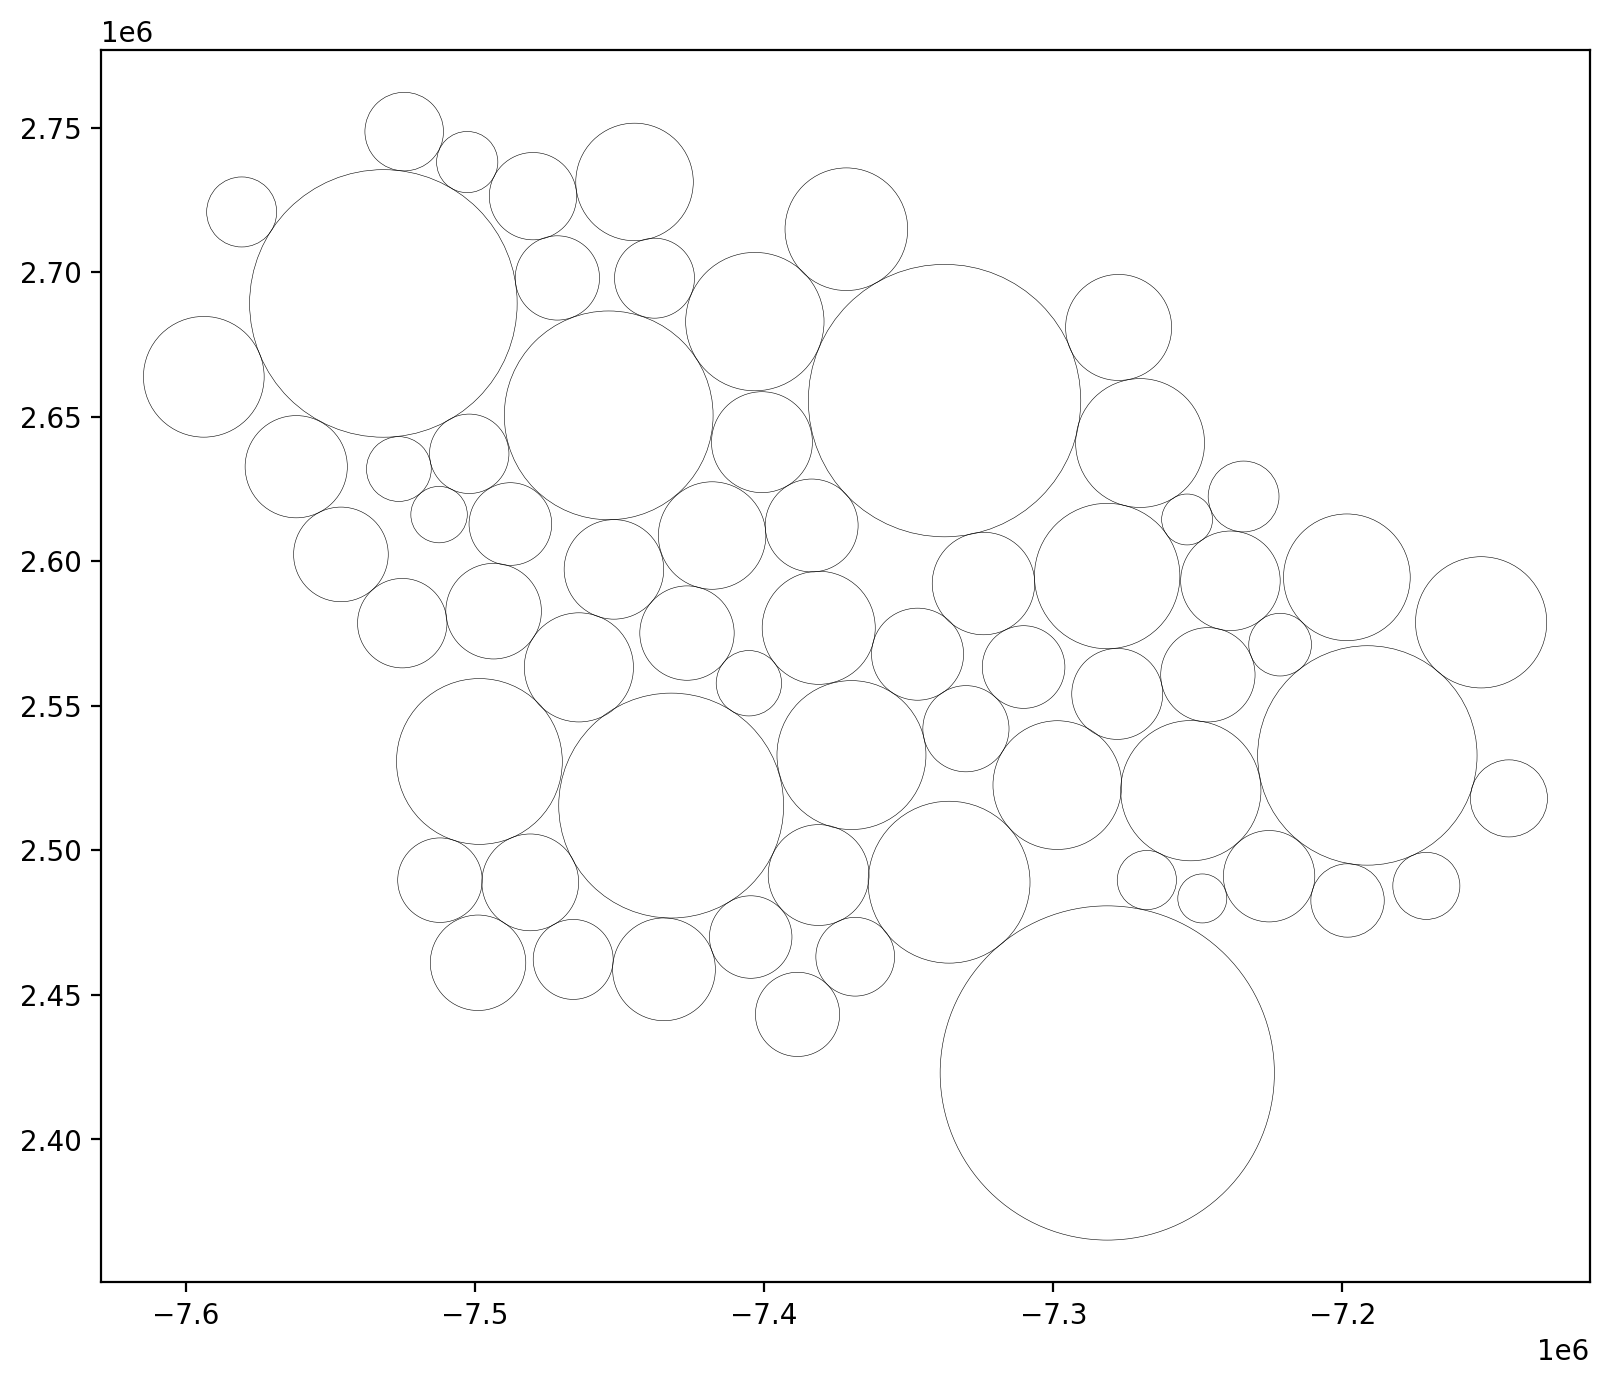

In [113]:
gdf_template = plotting.build_circle_template(
    gdf_adm2, id_col="ADM2_PCODE", pop_col="total_pop", area_per_person=20_000
)
plotting.plot_template_circles(gdf_template)

In [114]:
HOLGUIN2 = "CU0709"

In [115]:
df_exp[df_exp["ADM2_PCODE"] == HOLGUIN2]

,ADM1_PCODE,ADM1_ES,ADM2_PCODE,ADM2_ES,exp_34_knots,exp_50_knots,exp_64_knots,exp_100_mm,exp_200_mm,exp_300_mm,exp_400_mm,exp_500_mm,total_pop
44,CU07,Holguín,CU0709,Holguín,348796,348796,314951,348797,348797,0,0,0,348797


In [116]:
df_exp_wind[df_exp_wind["ADM2_PCODE"] == HOLGUIN2]

,ADM2_PCODE,buffer_speed,pop_exposed
44,CU0709,34,348796
111,CU0709,50,348796
178,CU0709,64,314951


In [141]:
import re


def wrap_text(text, max_len=10):
    """
    Insert line breaks at spaces or dashes so each line
    is roughly limited to `max_len` characters.
    Does not add or remove spaces/dashes.
    """
    tokens = re.findall(r"\S+-|\S+|[-]", text)  # split into words and dashes
    lines, current = [], ""

    for token in tokens:
        if len(current) + len(token) + 1 > max_len:
            lines.append(current.rstrip())
            current = token
        else:
            if current:
                current += " " if not current.endswith("-") else ""
            current += token

    if current:
        lines.append(current.rstrip())

    return "\n".join(lines).removeprefix("\n")

In [142]:
gdf_plot = gdf_template.merge(adm2_aoi[["ADM2_PCODE", "ADM2_ES"]])
gdf_plot["adm_label"] = gdf_plot["ADM2_ES"].apply(wrap_text)

Text(0.5, 1.0, 'Cuba: population exposed to Melissa wind speed per municipality\n')

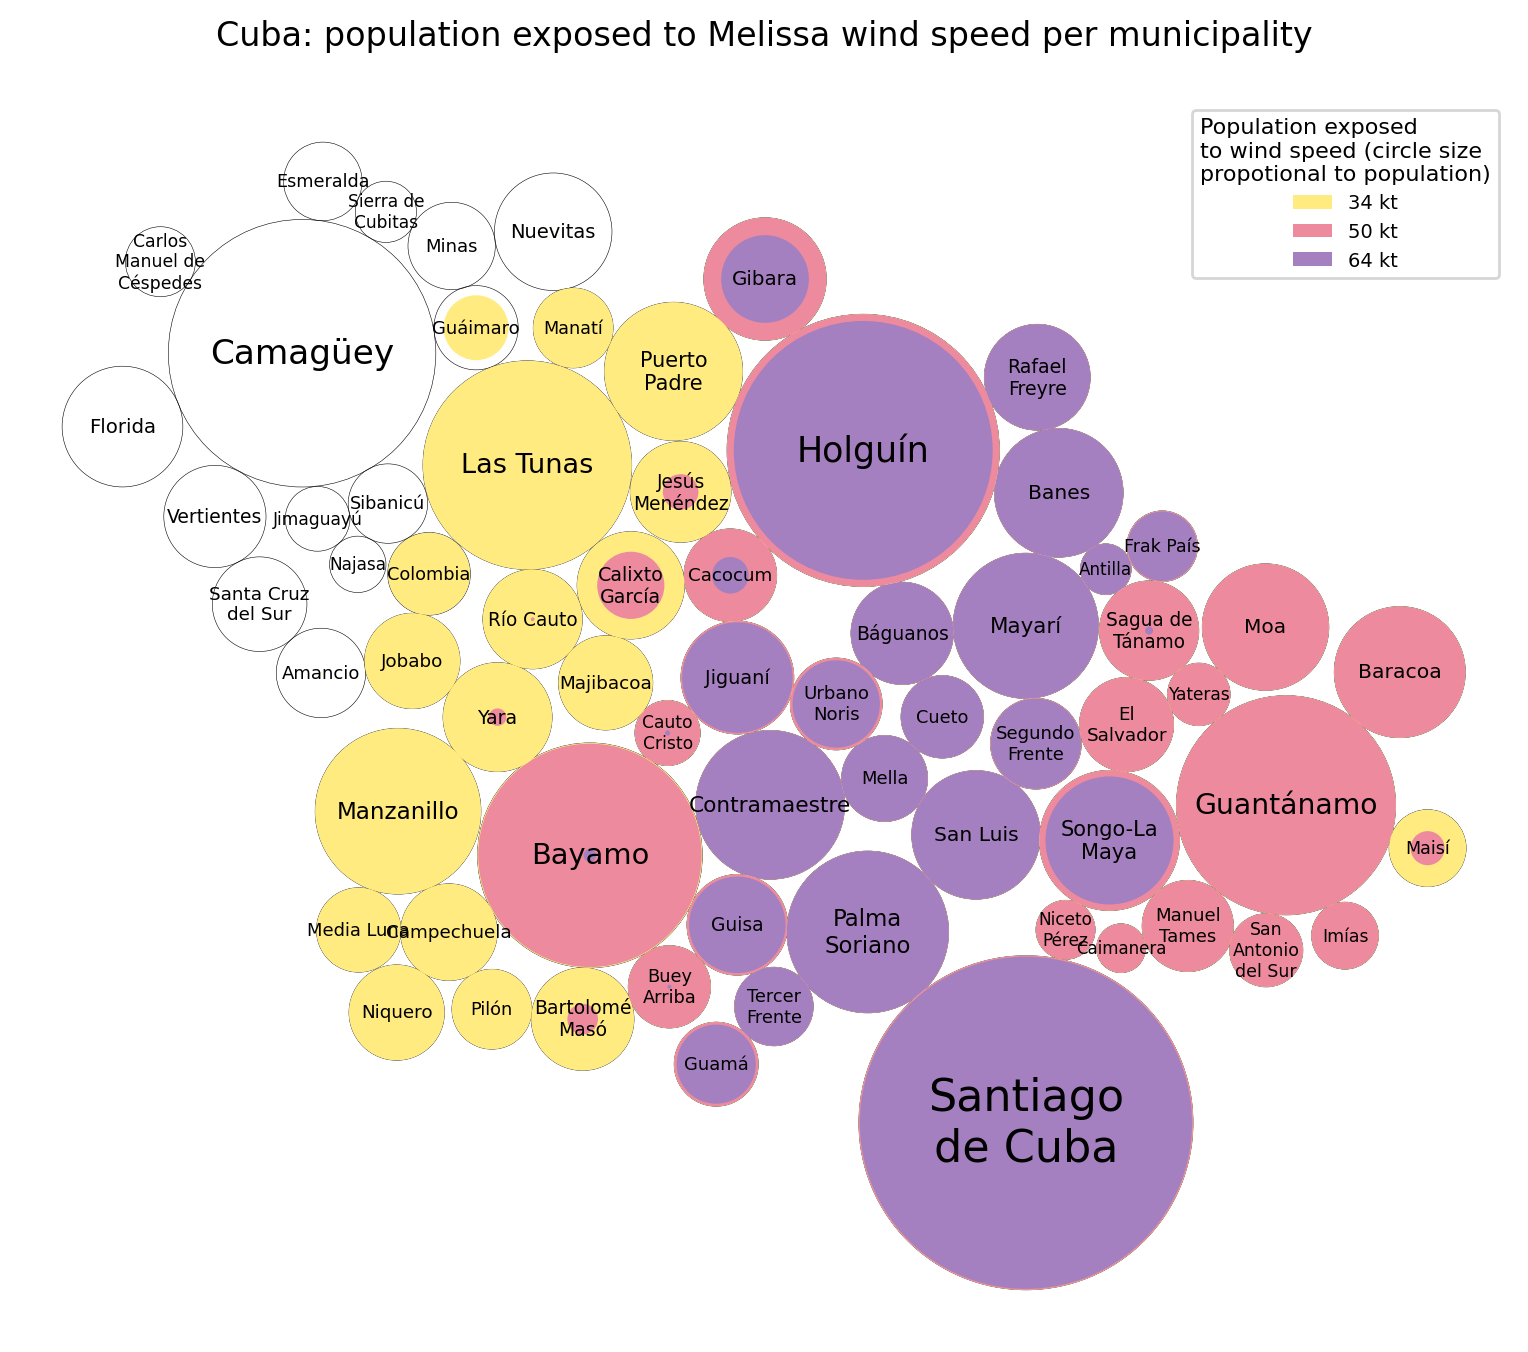

In [143]:
fig, ax = plotting.plot_bullseye_exposures(
    gdf_plot,
    df_exp_wind,
    id_col="ADM2_PCODE",
    label_col="adm_label",
    legend_title="Population exposed\nto wind speed (circle size\npropotional to population)",
)
ax.set_title(
    "Cuba: population exposed to Melissa wind speed per municipality\n"
)

In [118]:
df_exp_rain = df_exp.melt(
    id_vars=["ADM2_PCODE"],
    value_vars=[f"exp_{x}_mm" for x in [100, 200, 300, 400, 500]],
    var_name="rain_mm",
    value_name="pop_exposed",
)
df_exp_rain["rain_mm"] = (
    df_exp_rain["rain_mm"]
    .apply(lambda x: x.removeprefix("exp_").removesuffix("_mm"))
    .astype(int)
)
df_exp_rain

,ADM2_PCODE,rain_mm,pop_exposed
0,CU0201,100,0
1,CU0202,100,0
2,CU0203,100,0
3,CU0204,100,0
4,CU0205,100,12311
...,...,...,...
330,CU1505,500,0
331,CU1506,500,0
332,CU1507,500,0
333,CU1508,500,0


In [119]:
levels = [
    # 25,
    # 50,
    100,
    # 150,
    200,
    300,
    400,
    500,
    # 750,
]
colors = [
    # "lawngreen",
    # "limegreen",
    "yellow",
    # "gold",
    "darkorange",
    "red",
    "firebrick",
    "magenta",
    # "darkmagenta",
]

In [120]:
colors_dict = {l: c for l, c in zip(levels, colors)}

Text(0.5, 1.0, 'Cuba: population exposed to Melissa rainfall per municipality\nTotal rainfall over 2025-10-28 to 2025-10-29')

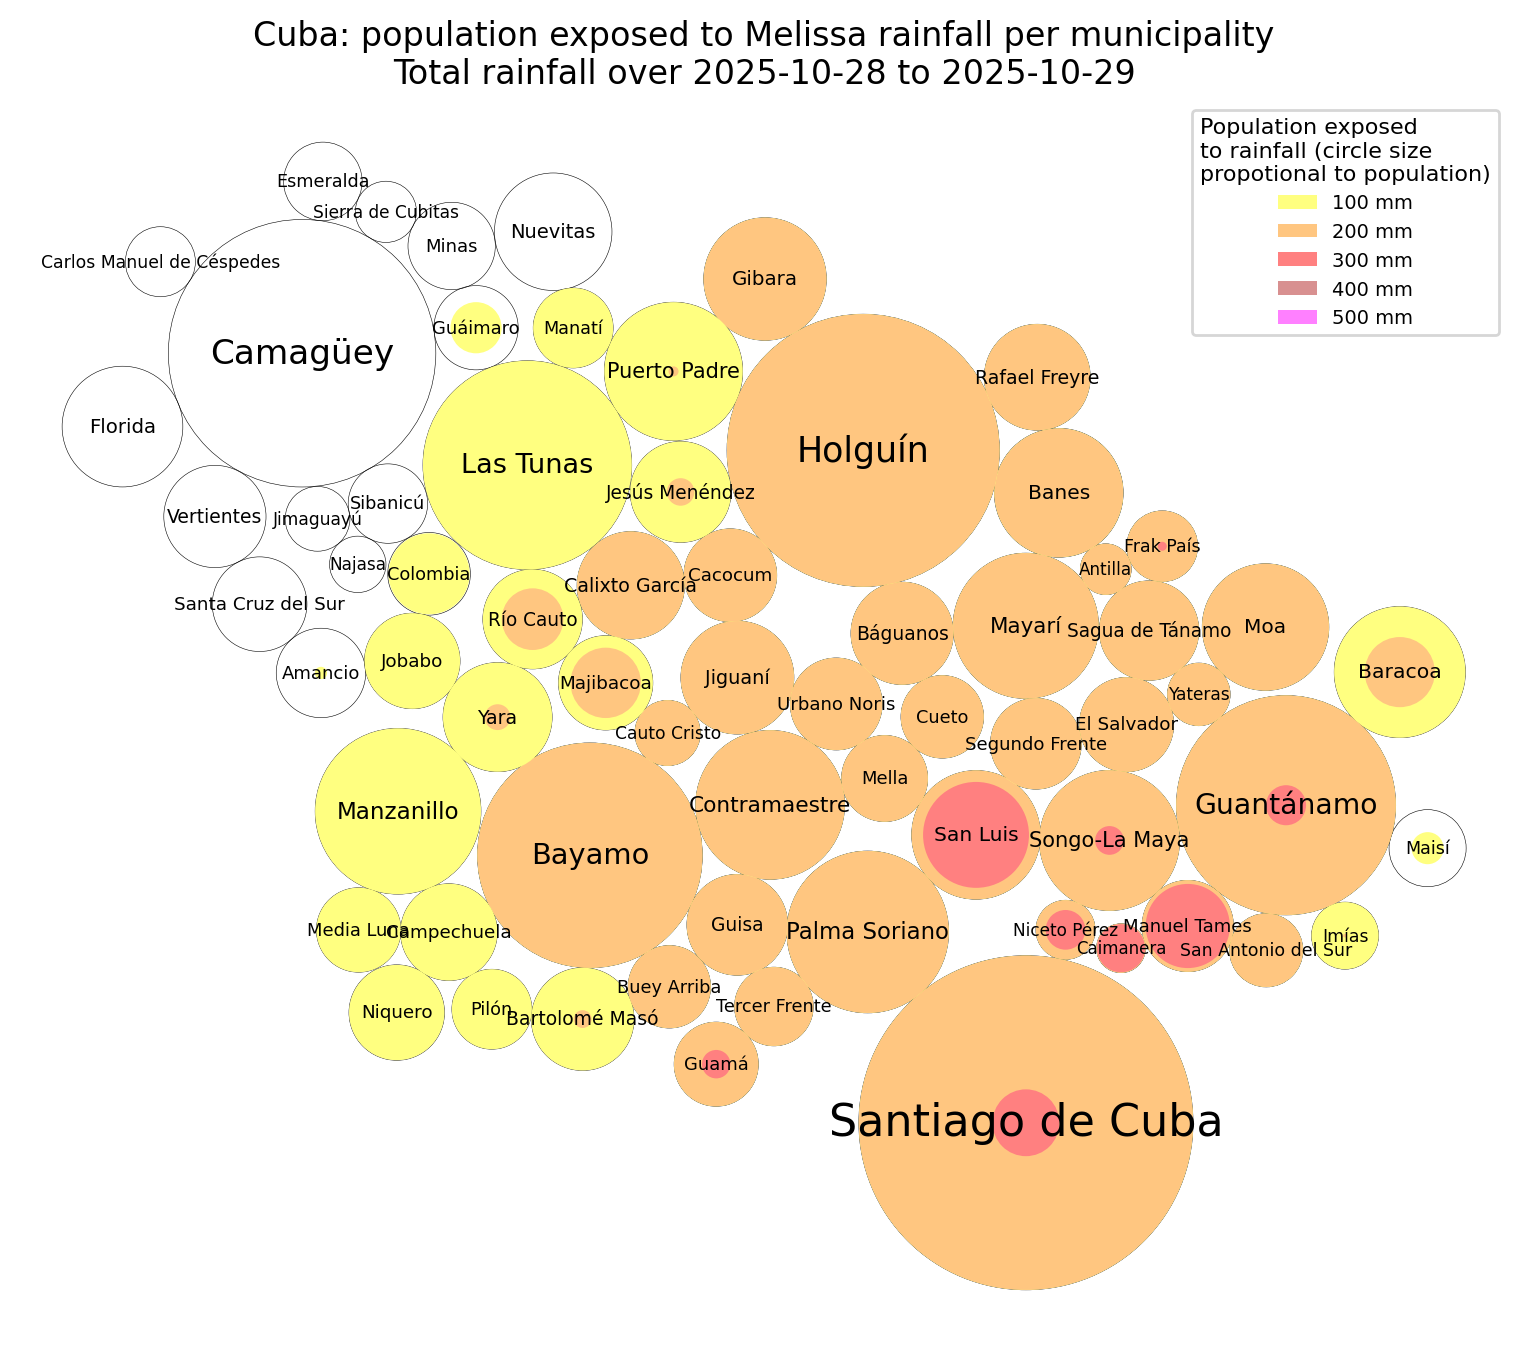

In [132]:
fig, ax = plotting.plot_bullseye_exposures(
    gdf_template.merge(adm2_aoi[["ADM2_PCODE", "ADM2_ES"]]),
    df_exp_rain,
    speed_col="rain_mm",
    speeds_order=levels,
    id_col="ADM2_PCODE",
    label_col="ADM2_ES",
    colors=colors_dict,
    legend_title="Population exposed\nto rainfall (circle size\npropotional to population)",
    legend_label_fmt="{spd} mm",
)
ax.set_title(
    "Cuba: population exposed to Melissa rainfall per municipality\n"
    "Total rainfall over 2025-10-28 to 2025-10-29"
)

In [153]:
blob_name = "ds-flood-gfm/processed/CUB_adm2_pop_exposure.csv"
df_exp_flood = stratus.load_csv_from_blob(blob_name)

In [154]:
df_exp_flood = df_exp_flood.rename(columns={"adm2_src": "ADM2_PCODE"})

In [155]:
df_exp_flood

,adm2_name,ADM2_PCODE,jrc_pop_exposed,chd_gfm_pop_exposed
0,Cauto Cristo,CU0505,5.0,583.0
1,Bayamo,CU0502,73.0,557.0
2,Río Cauto,CU0512,5.0,357.0
3,Caimanera,CU0602,62.0,308.0
4,Urbano Noris,CU0714,0.0,278.0
...,...,...,...,...
163,Guantánamo,CU0604,128.0,0.0
164,El Salvador,CU0603,0.0,0.0
165,Baracoa,CU0601,0.0,0.0
166,Niquero,CU0510,0.0,0.0


In [170]:
df_exp_flood = df_exp_flood.merge(
    adm2_aoi[["ADM2_PCODE", "ADM2_ES", "ADM1_PCODE", "ADM1_ES"]]
)

[None, None]

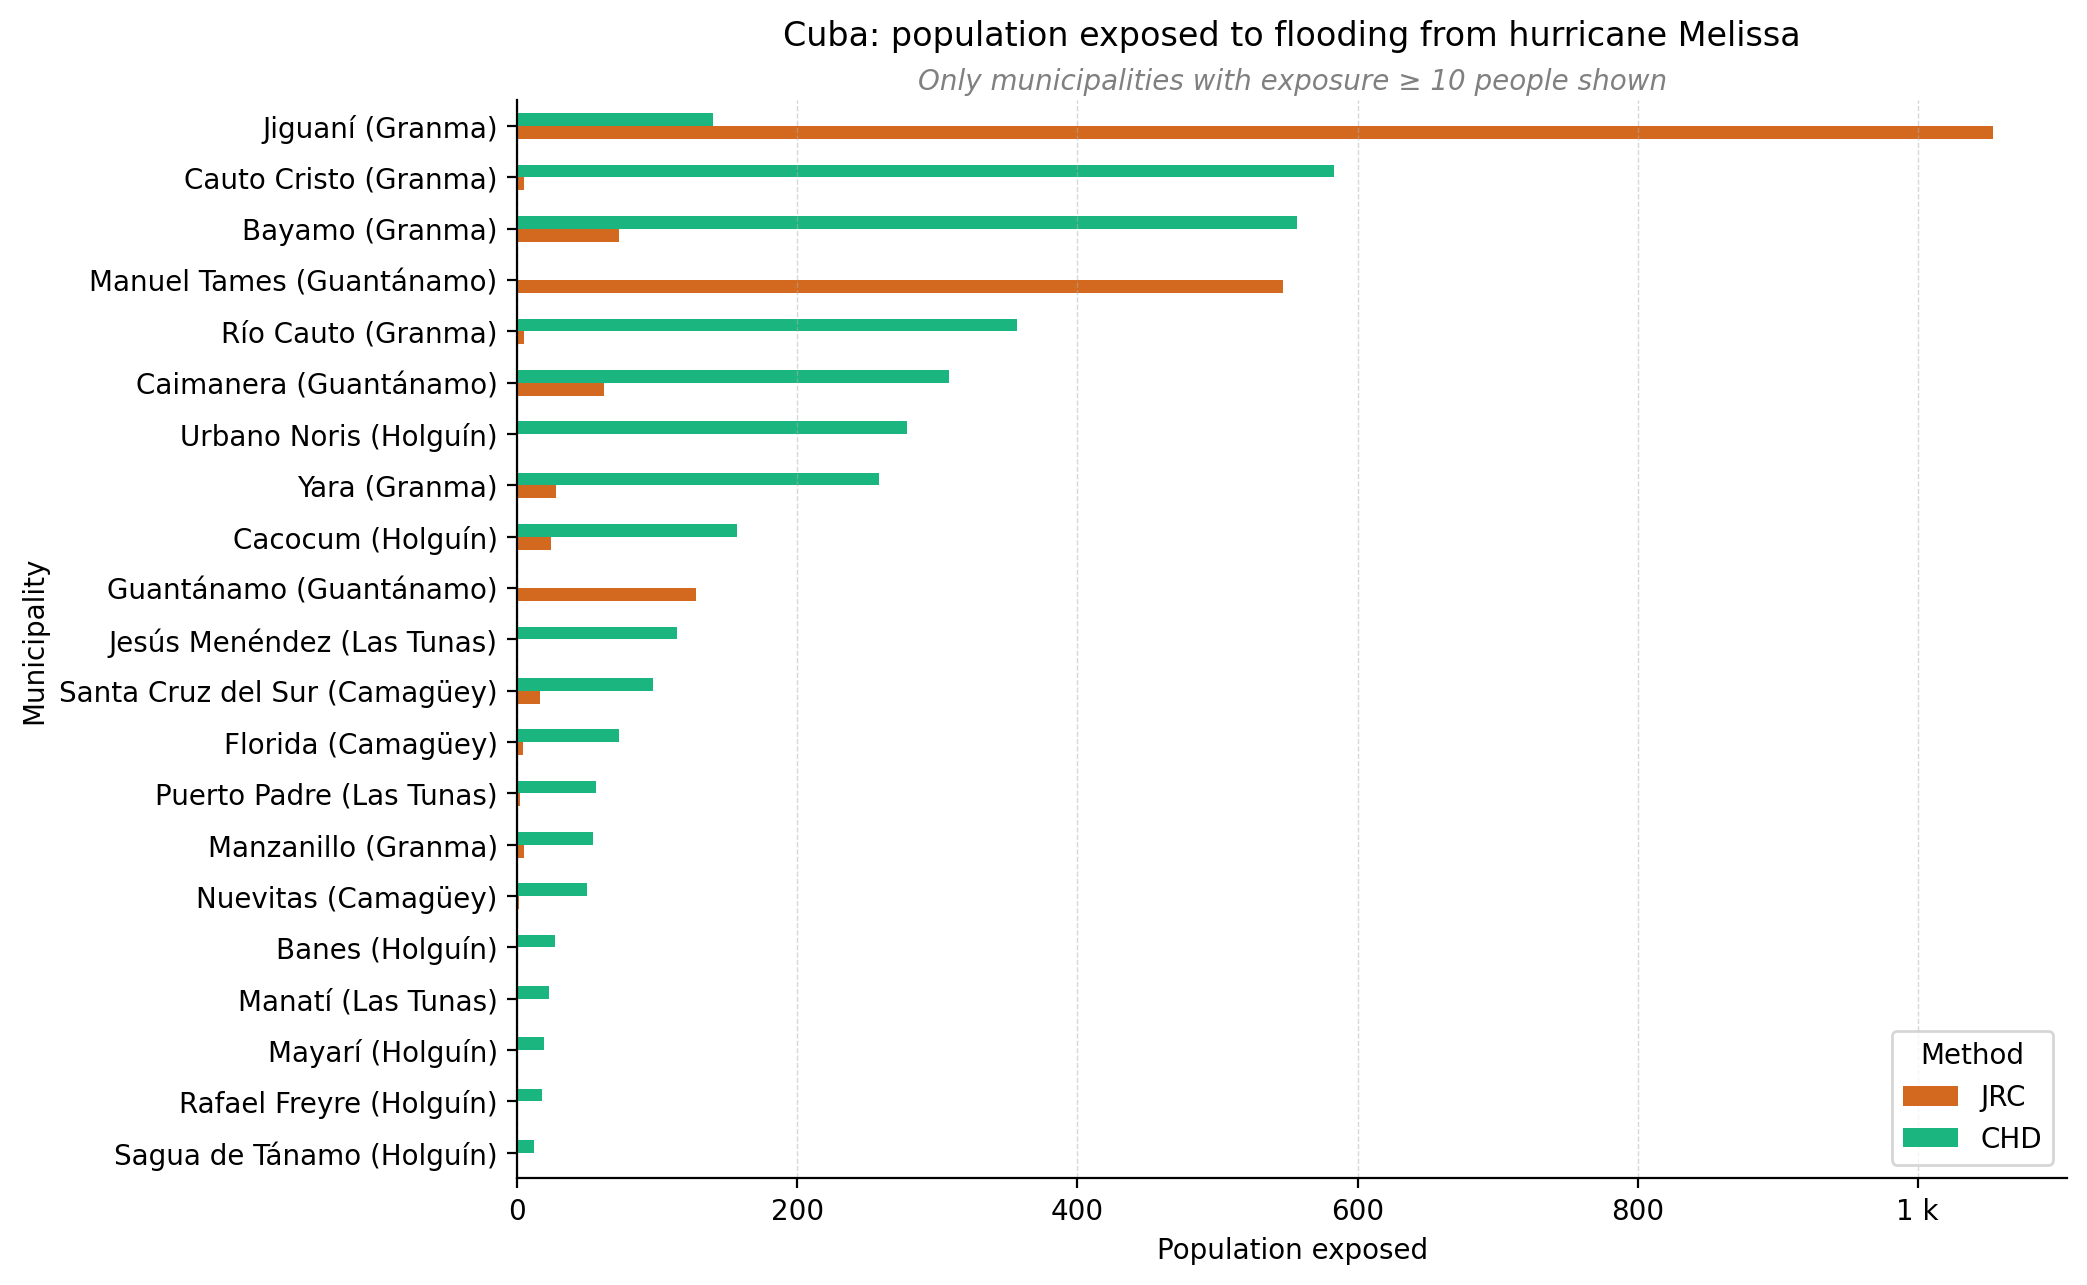

In [178]:
df_plot = df_exp_flood.copy()

df_plot["adm_label"] = df_plot["ADM2_ES"] + " (" + df_plot["ADM1_ES"] + ")"

cols = ["jrc_pop_exposed", "chd_gfm_pop_exposed"]

df_plot["max_cols"] = df_plot[cols].max(axis=1)

fig, ax = plt.subplots(figsize=(10, 7), dpi=200)

cutoff = 10

df_plot[df_plot["max_cols"] >= cutoff].sort_values("max_cols").plot.barh(
    x="adm_label",  # label (categorical axis)
    y=cols,  # numeric columns
    ax=ax,
    color=["chocolate", CHD_GREEN],
)

ax.legend(["JRC", "CHD"], title="Method")
ax.set_xlabel("Population exposed")
ax.set_ylabel("Municipality")

ax.set_title("Cuba: population exposed to flooding from hurricane Melissa\n")
ax.text(
    0.5,
    1.01,
    f"Only municipalities with exposure ≥ {cutoff} people shown",
    transform=ax.transAxes,
    ha="center",
    style="italic",
    color="grey",
)

ax.xaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.yaxis.grid(False)

ax.xaxis.set_major_formatter(EngFormatter(unit=""))
[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [181]:
df_out = (
    adm2_aoi[
        [
            "ADM1_PCODE",
            "ADM1_ES",
            "ADM2_PCODE",
            "ADM2_ES",
        ]
    ]
    .merge(df_exp_flood)
    .sort_values(["ADM1_ES", "ADM2_ES"])
)

In [183]:
save_path = "temp/cub_melissa_adm2_flood_exposure.csv"
df_out.to_csv(save_path, index=False, encoding="utf-8-sig")

save_path = "temp/cub_melissa_adm2_flood_exposure.xlsx"
df_out.to_excel(save_path, index=False)